# Convolutional Neural Network (CNN) Classification - Handwritten Digit Recognition

## Project Overview

This project builds a CNN to classify handwritten digits from the MNIST dataset using TensorFlow/Keras.

## 1. Import Required Libraries

Import all required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix

## 2. Load Dataset

Load MNIST from TensorFlow.

In [2]:
(x_train,y_train),(x_test,y_test)=mnist.load_data();print(x_train.shape,x_test.shape)

(60000, 28, 28) (10000, 28, 28)


## 3. Explore Dataset

Visualize sample images and class distribution.

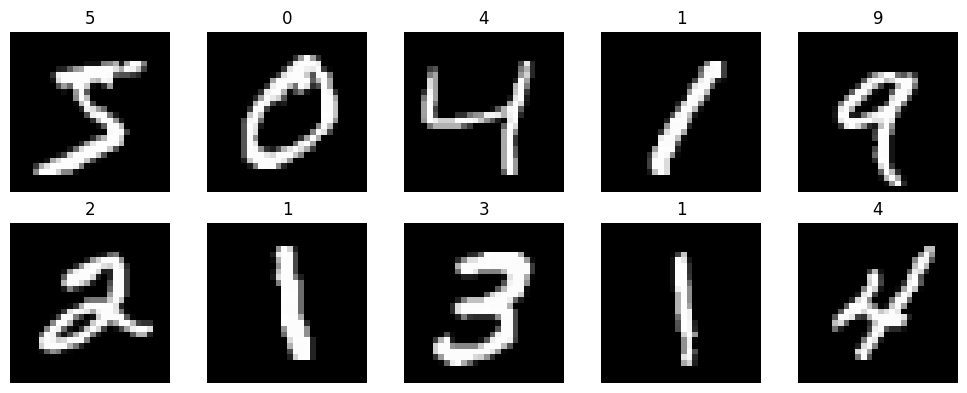

[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [3]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1);plt.imshow(x_train[i],cmap='gray');plt.title(y_train[i]);plt.axis('off')
plt.tight_layout();plt.show()
print(np.bincount(y_train))

## 4. Preprocess Images

Normalize, reshape and encode labels.

In [4]:
x_train=x_train.astype('float32')/255;x_test=x_test.astype('float32')/255
x_train=x_train.reshape(-1,28,28,1);x_test=x_test.reshape(-1,28,28,1)
y_train_cat=to_categorical(y_train,10);y_test_cat=to_categorical(y_test,10)

## 5. Build CNN Model

Create the CNN architecture.

In [5]:
model=Sequential([
Input(shape=(28,28,1)),
Conv2D(32,(3,3),activation='relu'),
MaxPooling2D((2,2)),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D((2,2)),
Flatten(),
Dense(128,activation='relu'),
Dropout(0.3),
Dense(10,activation='softmax')])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

Train with early stopping.

In [6]:
early=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history=model.fit(x_train,y_train_cat,validation_split=0.2,epochs=15,batch_size=64,callbacks=[early],verbose=1)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9325 - loss: 0.2192 - val_accuracy: 0.9799 - val_loss: 0.0642
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9772 - loss: 0.0727 - val_accuracy: 0.9862 - val_loss: 0.0485
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9837 - loss: 0.0524 - val_accuracy: 0.9868 - val_loss: 0.0423
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9870 - loss: 0.0402 - val_accuracy: 0.9897 - val_loss: 0.0388
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.9878 - val_loss: 0.0433
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.9902 - val_loss: 0.0376
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9924 - loss: 0.0241 - val_accuracy: 0.9916 - val_loss: 0.0325
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9931 - loss: 0.0209 - val_accuracy

## 7. Training Curves

Plot learning curves.

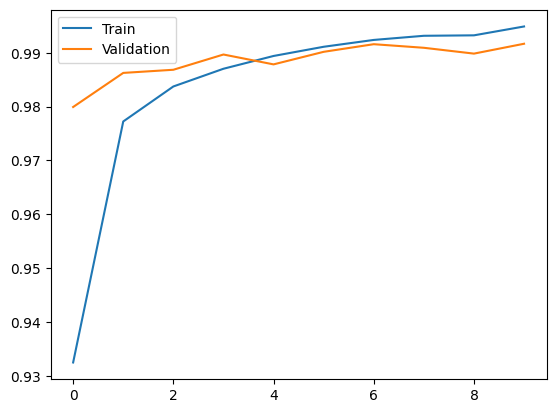

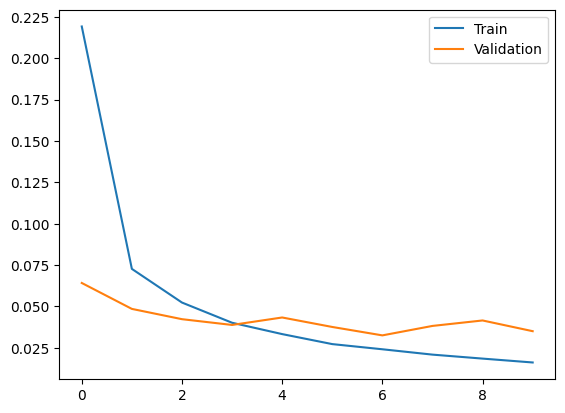

In [7]:
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.legend();plt.show()
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend();plt.show()

## 8. Evaluate Model

Evaluate on the test set.

In [8]:
loss,acc=model.evaluate(x_test,y_test_cat,verbose=0);print(f'Test Accuracy: {acc:.4f}')

Test Accuracy: 0.9914


## 9. Classification Report

Generate precision, recall and F1.

In [9]:
pred=model.predict(x_test,verbose=0)
pred_labels=np.argmax(pred,axis=1)
print(classification_report(y_test,pred_labels))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      1.00      1032
           3       0.98      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 10. Confusion Matrix

Visualize predictions.

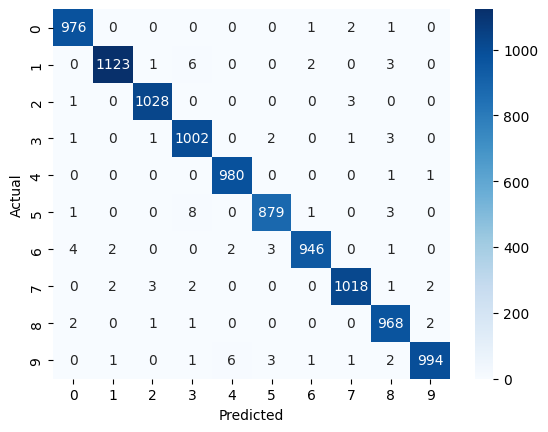

In [10]:
cm=confusion_matrix(y_test,pred_labels)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted');plt.ylabel('Actual');plt.show()

## 11. Sample Predictions

Display sample predictions.

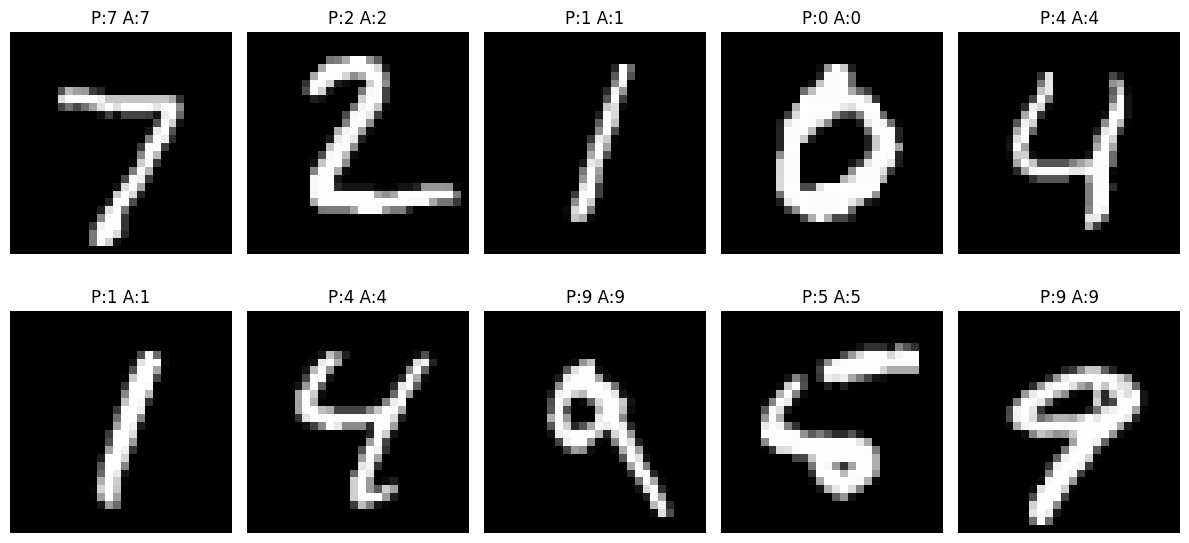

In [11]:
plt.figure(figsize=(12,6))
for i in range(10):
 plt.subplot(2,5,i+1);plt.imshow(x_test[i].reshape(28,28),cmap='gray');plt.title(f'P:{pred_labels[i]} A:{y_test[i]}');plt.axis('off')
plt.tight_layout();plt.show()

## 12. Key Findings

- The Convolutional Neural Network achieved a **test accuracy of approximately 99.14%**, demonstrating excellent handwritten digit classification performance on unseen data.
- Training and validation accuracy converged smoothly while validation loss remained stable, indicating effective learning without significant overfitting.
- The classification report showed consistently high precision, recall, and F1-scores across all digit classes, with only a small number of misclassifications observed in the confusion matrix.
- The CNN successfully learned meaningful spatial features from the input images through convolution and pooling operations, resulting in highly accurate predictions.

## 13. Conclusion

This project demonstrates the effectiveness of a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset. By combining image preprocessing, convolutional feature extraction, pooling, regularization, and early stopping, the model achieved excellent generalization performance on unseen test data with an accuracy of approximately 99.14%. The project provides a complete and reproducible deep learning workflow for image classification and serves as a strong foundation for more advanced computer vision tasks.